# Física Computacional 2 - Métodos de Monte Carlo 1

## 1. Introdução

Sistemas com um número grande de graus de liberdade são comuns na Física. Por exemplo, átomos em um pedaço de matéria condensada, átomos de muitos elétrons ou o valor de um campo quântico em uma região do espaço-tempo. Nesses sistemas, o cálculo da função de partição leva a uma integral de dimensão altíssima. Resolver tal integral por um método de quadratura convencional (e.g. trapézios) poderia levar mais que a idade do universo!

Os Métodos de Monte Carlo que serão apresentados são maneiras eficientes de se calcular integrais de dimensão alta. A estratégia básica do método é calcular o integrando apenas em uma amostragem aleatória, porém representativa, de pontos. Seria como prever uma eleição por meio de uma pesquisa eleitoral.

### Estratégia básica do método

Considere que queremos calcular a integral

$$
I=\int_0^1f(x)dx\;\;\;\;\; (1)
$$

Ao invés de utilizar os métodos de Newton-Cotes, como visto em Física Computacional1, uma maneira alternativa é pensar na integral como uma média da função no intervalo $[0,1]$. A fórmula de quadratura seria,

$$
I\approx\frac{1}{N}\sum_{i=1}^{N}f(x_i)
$$
onde a média de $f$ é calculada considerando $N$ valores das abscissas $\{x_i\}$ escolhidas aleatoriamente com igual probabilidade no intervalo  $[0,1]$.

Considerando $f_i=f(x_i)$ como uma variável aleatória, pode-se invocar o teorema do limite central, e obter uma estimativa para a incerteza associada ao cálculo da integral acima. Pelas regras usuais da estatística,

$$
\sigma_I^2=\frac{1}{N}\sigma_f^2=\frac{1}{N}\left[\frac{1}{N}\sum_{i=1}^N f_i^2-\left(\frac{1}{N}\sum_{i=1}^N f_i\right)^2\right]
$$
onde $\sigma_f^2$ é a variância em $f$, uma medida de quanto $f$ desvia da média na região de integração. A equação acima revela aspectos importantes da quadratura de Monte Carlo. Primeiro, a incerteza na estimativa da integral decresce com $N^{-1/2}$ (método dos trapézios escala com $N^{-2}$, mas a vantagem cessa para integrais multidimensionais). O segundo ponto importante é que a precisão vai ser maior se $\sigma_f$ for menor, ou seja se $f$ for uma função muito suave. Um limite extremo é quando $f$ for uma função constante, daí só precisamos de um ponto para calcular sua média. Um outro caso extermo seria quando $f$ for zero em todo o intervalo exceto em um pico estreito em torno de um certo valor $x$.  








---
<font color='red'> EXERCÍCIO 1 </font> Como exemplo do método, calcule a integral abaixo
$$
\int_0^1\frac{1}{1+x^2}dx=\frac{\pi}{4}\approx0.78540
$$
e de $\sigma_I$ para diversos valores de $N$ entre $10$ e $5000$.

A biblioteca numpy possui um gerador de números pseudoaleatórios. Utilize, por exemplo, x=np.random.rand(), que gera um número aleatório entre $0$ e $1$.
Outra biblioteca é a random. Para gerar um número aleatório x entre $0$ e $1$, utilize x=random.random().



----

In [1]:
import numpy as np

def func(x):
    return 1/(1+x**2) 

vexato=np.pi/4

for N in (10,20,50,100,200,500,1000,2000,5000):
    soma=0.
    soma2=0.
    for i in range(N):
        xi=np.random.rand()
        fx=func(xi)
        soma+=fx
        soma2+=fx**2
    media=soma/N
    media2=soma2/N
    sigma=np.sqrt((media2-media**2)/N) # variância
    print("N={:4} Integral= {:.6f} +- {:.6f} erro= {:.6f}".format(N,media,sigma,abs(vexato-media)) )


print("\nValor exato= ",vexato)

N=  10 Integral= 0.701319 +- 0.051062 erro= 0.084079
N=  20 Integral= 0.840940 +- 0.031513 erro= 0.055542
N=  50 Integral= 0.773587 +- 0.023838 erro= 0.011811
N= 100 Integral= 0.788082 +- 0.016151 erro= 0.002684
N= 200 Integral= 0.799300 +- 0.011246 erro= 0.013902
N= 500 Integral= 0.795024 +- 0.006828 erro= 0.009626
N=1000 Integral= 0.793843 +- 0.005055 erro= 0.008444
N=2000 Integral= 0.780401 +- 0.003595 erro= 0.004997
N=5000 Integral= 0.784966 +- 0.002303 erro= 0.000433

Valor exato=  0.7853981633974483


Para se reduzir a variância e aumentar a eficiência do método deve-se procurar uma função peso positiva $w(x)$ tal que,

$$
\int_0^1 w(x)dx=1.
$$

Multiplicando e dividindo o integrando por $w(x)$, obtemos

$$
I=\int_0^1 w(x)\frac{f(x)}{w(x)}dx
$$
Agora fazemos uma mudança de variável para $y$,

$$
y(x)=\int_0^x dx'w(x'),
$$
assim temos,
$$
\frac{dy}{dx}=w(x) \;\;\;\;\;\;\;\;\;\; y(x=0)=0  \;\;\;\;\;\;\;\;\;\; y(x=1)=1,
$$
podemos então reescrever a integral como,
$$
I=\int_0^1 \frac{f(x(y))}{w(x(y))}dy.
$$

A integral é calculada pela média de $f/w$ distribuindo os pontos aleatoriamente de forma uniforme em $y$ no intervalo $[0,1]$,

$$
I\approx\frac{1}{N}\sum_{i=1}^{N} \frac{f(x(y_i))}{w(x(y_i))}
$$
Note que se escolhermos $w(x)$ com um comportamento similar ao de $f(x)$ (grande quando $f$ for grande, pequeno quando $f$ for pequeno) a razão $f(x)/w(x)$ tende a ficar bastante suave, diminuindo a variância. Outra maneira de se entender esse procedimento é pensar que uma distribuição uniforme em $y$, implica que a distribuição em $x$ é $dy/dx=w(x)$. Isso significa que os pontos estão distribuídos nos valores mais importantes de $x$, onde $w$ e $f$ têm valores apreciáveis.  




---
<font color='red'> EXERCÍCIO 2 </font> Calule a integral do Exercício 1 e a variância para vários valores de $N$, considerando a seguinte função peso,
$$
w(x)=\frac{1}{3}(4-2x).
$$
Verifique que $w(x)$ e $f(x)$ têm comportamento semelhantes e note que,
$y=\frac{1}{3}x(4-x)$, $x=2-(4-3y)^{1/2}$






----

In [2]:
import numpy as np

def func(x):
    return 1/(1+x**2) 

def w(x):
    return (4-2*x)/3

def x(y):
    return 2-np.sqrt(4-3*y)


vexato=np.pi/4


for N in (10,20,50,100,200,500,100,2000,5000):
    soma=0.
    soma2=0.
    for i in range(N):
        yi=np.random.rand()
        fxwx=func(x(yi))/w(x(yi))
        soma+=fxwx
        soma2+=fxwx**2
    media=soma/N
    media2=soma2/N
    sigma=np.sqrt((media2-media**2)/N) # variância
    print("N={:4} Integral= {:.6f} +- {:.6f} erro= {:.6f}".format(N,media,sigma,abs(vexato-media)) )
    

print("\nValor exato= ",vexato)

N=  10 Integral= 0.771418 +- 0.006680 erro= 0.013981
N=  20 Integral= 0.783951 +- 0.004735 erro= 0.001447
N=  50 Integral= 0.781243 +- 0.002901 erro= 0.004155
N= 100 Integral= 0.783512 +- 0.001976 erro= 0.001886
N= 200 Integral= 0.785515 +- 0.001510 erro= 0.000117
N= 500 Integral= 0.785581 +- 0.000878 erro= 0.000183
N= 100 Integral= 0.788990 +- 0.001930 erro= 0.003591
N=2000 Integral= 0.785269 +- 0.000450 erro= 0.000130
N=5000 Integral= 0.785800 +- 0.000283 erro= 0.000401

Valor exato=  0.7853981633974483


---
<font color='red'> EXERCÍCIO 3 </font> Calcule a seguinte integral pelo método de Monte Carlo:

$$
4\int_0^1dx_1\int_0^1 \theta(1-x_1^2-x_2^2) dx_2=\pi,
$$
onde $\theta$ é a função degrau de Heaviside ($\theta(x)=0$ se $x<0$ e $\theta(x)=1$ se $x>0$). O comando np.random.rand(2) gera uma array de tamanho $2$ com números aleatórios entre $0$ e $1$.


----

In [5]:
import numpy as np

while True:
    N=int(input("\nEntre como o número de pontos para a integração ou zero para sair "))
    if N==0: break
    cont=0
    for i in range(N):
        xi=np.random.rand(2)
        if xi[0]**2+xi[1]**2<1:cont+=1
    integ=cont/N  
    sigma=np.sqrt(integ*(1-integ)/N)  
    integ*=4
    erro=abs(integ-np.pi)
    print("{:.6f}  {:.6f}  {:.6f}".format(integ,erro,sigma))
    

3.160000  0.018407  0.040731
3.212000  0.070407  0.012577
3.220000  0.078407  0.028016
3.040000  0.101593  0.042708
3.040000  0.101593  0.019100
3.168000  0.026407  0.012835


## 2. Gerando números aleatórios com uma distribuição específica


Considere que queremos calcular uma integral da forma,

$$
I=\int_0^\infty e^{-x}g(x)dx
$$
De acordo com a discussão da seção anterior, é razoável gerar pontos entre $0$ e $\infty$ com distribuição $w(x)=e^{-x}$ e depois calcular a média de $g$ sobre esses pontos. Considerando $dy=e^{-x}dx$, temos

$$
y=1-e^{-x} \;\;\;\; x=-\ln(1-y)
$$


---
<font color='red'> EXERCÍCIO 4 </font> Calcule a seguinte integral pelo método de Monte Carlo utilizando uma distribuição de pontos de acordo com $e^{-x}$.

$$
\int_0^{\infty}dx e^{-x}x^2,
$$



----

In [ ]:
import numpy as np
def x(y):
  return -np.log(1.-y)
som=0
N=5000
for i in range(N):
  y=np.random.rand()
  som+=x(y)**2/N
print(som)

2.0242681818074


In [6]:
import numpy as np

def x(y):
    return -np.log(1-y)

def func(x):
    return x**2

for N in (100,200,500,100,2000,5000,10000,20000,50000,100000,500000,1000000):
    soma=0.
    soma2=0.
    for i in range(N):
        y=np.random.rand()
        fx=func(x(y))
        soma+=fx
        soma2+=fx**2
    media=soma/N
    media2=soma2/N
    sigma=np.sqrt((media2-media**2)/N) # variância
    print("N={:7} Integral= {:.7f} +- {:.7f}".format(N,media,sigma))


N=    100 Integral= 1.7573514 +- 0.3248785
N=    200 Integral= 2.1342234 +- 0.4354972
N=    500 Integral= 2.0040583 +- 0.2207911
N=    100 Integral= 1.7199194 +- 0.3323952
N=   2000 Integral= 1.9289743 +- 0.0902745
N=   5000 Integral= 2.0694344 +- 0.0645536
N=  10000 Integral= 1.9551498 +- 0.0431095
N=  20000 Integral= 1.9730439 +- 0.0303029
N=  50000 Integral= 2.0059935 +- 0.0195050
N= 100000 Integral= 1.9857819 +- 0.0140338
N= 500000 Integral= 1.9918594 +- 0.0062843
N=1000000 Integral= 1.9990659 +- 0.0044831


Outro método conveniente para gerar uma distribuição é o método da rejeição de von Neuman, cuja ideia geométrica está ilustrada na figura abaixo. Suponha que desejamos gerar $x$ entre $0$ e $1$ com uma distribuição $w(x)$ e seja $w'(x)$ uma função positiva tal que $w'(x)>w(x)$ sobre a região de integração. Note que a integral definida de $w'(x)$ é maior que $1$. Uma escolha conveniente seria $w'(x)$ igual a uma constante maior que o valor máximo de $w(x)$ no intervalo. Se gerarmos pontos em duas dimensões que preenchem uniformemente a área sob a curva $w'(x)$ e então aceitar para uso somente aqueles pontos que estão abixo de $w(x)$, então os pontos selecionados estarão distribuídos de acordo com $w(x)$. Na prática, geramos dois números aleatórios $x_i$ e $\eta$, o primeiro distribuído proporcionalmente à $w'(x)$ e o segundo distribuído uniformemente entre $0$ e $1$. O valor de $x_i$ será aceito se $\eta$ for menor que a razão $w(x_i)/w'(x_i)$. Se o ponto for rejeitado, simplemente passamos para o próximo ponto. Essa ténica é eficiente se $w'(x)$ é próxima de $w(x)$ em todo intervalo de integração.



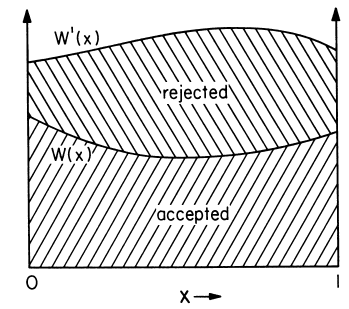

---
<font color='red'> EXERCÍCIO 5 </font> Aplique o método da rejeição de von Neuman para gerar pontos no intervalo $[0,1]$ distribuídos de acordo com,
$$
w(x)=\frac{6}{5}(1-\frac{x^2}{2}).
$$
Utilize esses pontos para calcular a integral dos Exercícios 1 e 2.


----

In [7]:
import numpy as np


def func(x):
    return 5/(6*(1+x**2)*(1-0.5*x**2)) 

def w(x):
    return 6*(1-0.5*x**2)/5

def wp(x):
    return 1.21

def vonNeuman():
   while True:
       xi,eta=np.random.rand(2)
       if eta<w(xi)/wp(xi):
           return xi

vexato=np.pi/4


for N in (10,20,50,100,200,500,100,2000,5000,10000):
    soma=0.
    soma2=0.
    for i in range(N):
        xi=vonNeuman()
        fx=func(xi)
        soma+=fx
        soma2+=fx**2
    media=soma/N
    media2=soma2/N
    sigma=np.sqrt(media2-media**2)/N # variância
    print("N={:6} Integral= {:.7f} +- {:.7f} erro= {:.7f}".format(N,media,sigma,abs(vexato-media)) )
    

print("\nValor exato= ",vexato)


N=    10 Integral= 0.7870516 +- 0.0028624 erro= 0.0016535
N=    20 Integral= 0.7863933 +- 0.0018183 erro= 0.0009952
N=    50 Integral= 0.7833973 +- 0.0006526 erro= 0.0020008
N=   100 Integral= 0.7779780 +- 0.0003209 erro= 0.0074202
N=   200 Integral= 0.7845502 +- 0.0001646 erro= 0.0008480
N=   500 Integral= 0.7851401 +- 0.0000637 erro= 0.0002581
N=   100 Integral= 0.7867657 +- 0.0003326 erro= 0.0013675
N=  2000 Integral= 0.7847046 +- 0.0000162 erro= 0.0006935
N=  5000 Integral= 0.7855403 +- 0.0000065 erro= 0.0001421
N= 10000 Integral= 0.7854164 +- 0.0000033 erro= 0.0000182

Valor exato=  0.7853981633974483


A distribuição Gaussiana (ou distribuição normal) com valor médio igual a zero e variância igual a um é dada por,

$$
w(x)=\frac{1}{\sqrt{2\pi}}e^{-\frac{x^2}{2}}
$$
Esta distribuição desempenha um papel central em probabilidade e é muito usada em cálculos com métodos de Monte Carlo.

Para gerar a distribuição Gaussiana, considere a distribuição em duas dimensões $(x_1,x_2)$,
$$
e^{-\frac{1}{2}\left(x_1^2+x_2^2\right)}dx_1dx_2.
$$
Fazendo a transformação para coordenadas polares,
$$
r=\sqrt{x_1^2+x_2^2} \;\;\;\;\; \theta=\tan^{-1}\left(\frac{x_2}{x_1}\right),
$$
a distribuição torna-se,
$$
e^{-\frac{1}{2}r^2}rdrd\theta.
$$
Com uma nova variável $u=\frac{1}{2}r^2$, a distribuição fica,
$$
e^{-u}dud\theta.
$$
Desta forma, se gerarmos $u$ com distribuição exponencial entre $0$ e $\infty$ e $\theta$ uniformemente entre $0$ e $2\pi$, as duas variáveis,

$$
x_1=\sqrt{2u}\cos(\theta) \;\;\;\;\;\;\; x_2=\sqrt{2u}\sin(\theta),
$$
estarão distribuídas de acordo com a distribuição normal.


---
<font color='red'> EXERCÍCIO 6 </font> Faça um histograma da distribuição gaussiana em uma dimensão utilizando um número grande de pontos.


----

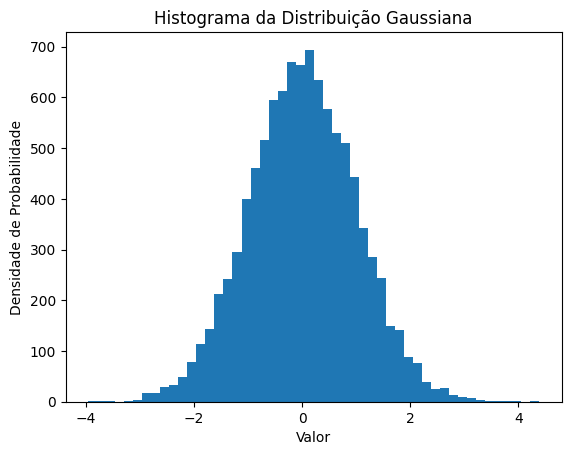

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def gaussiana():
    a=np.random.rand(2)
    theta=2*np.pi*a[0]
    u=-np.log(1-a[1])
    r=np.sqrt(2*u)
    x1=r*np.cos(theta)
    x2=r*np.sin(theta)
    return x1,x2

n=10000
d=0.1
L=4
N=round(L/d)
hist=np.zeros((2*N,2*N))
xh=np.array([])

for i in range(n):
    x,y=gaussiana()
    xh=np.append(xh, x)
    if abs(x)<=L and abs(y)<=L:
       nx=round((x+L)/d);ny=round((y+L)/d)
       hist[nx,ny]=hist[nx,ny]+1


plt.hist(xh, bins=50)
plt.title('Histograma da Distribuição Gaussiana')
plt.xlabel('Valor')
plt.ylabel('Densidade de Probabilidade')
plt.show()